# Cap 3: Experimentos estadisticos y pruebas de significancia

### Configurar entorno

In [1]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

In [2]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

Definimos las rutas de cada dataset que vamos a utilizar

In [3]:
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

### Remuestreo

Vamos a comparar el tiempo promedio de sesion en dos paginas web: A y B.

In [4]:
# obtener los datos de las paginas web
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)

# convertir tiempo a segundos
session_times.Time = 100*session_times.Time
session_times.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


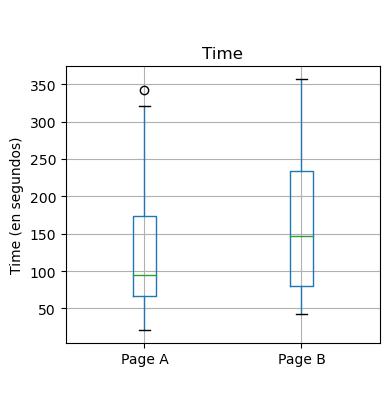

In [5]:
# crear boxplot del tiempo de cada pagina
ax = session_times.boxplot(by='Page', column='Time', figsize=(4,4))
ax.set_xlabel(' ')
ax.set_ylabel('Time (en segundos)')
plt.suptitle(' ')
plt.tight_layout()
plt.show()

> Se evidencia que la pagina B conduce a sesiones mas largas que la pagina A.

In [6]:
# calcular las medias de tiempo de cada pagina
mean_A = session_times[session_times.Page == 'Page A'].Time.mean()
mean_B = session_times[session_times.Page == 'Page B'].Time.mean()

# obtener la diferencia de la media entre paginas
print(mean_B - mean_A)

35.66666666666667


> La diferencia de tiempo entre la sesion de la pagina A y B, en promedio, es de 36 segundos. Esto sugiere que la pagina B tiene tiempos de sesion mayores a los de la pagina A lo que se traduce en mayor efectividad en cuanto a las ventas. Sin embargo, debe probarse si esta diferencia esta dentro del rango de lo que el azar podria producir.

Vamos a crear una prueba de permutacion para evaluar si una diferencia observada entre dos grupos es estadisticamente significativa. Se calcula la diferencia en los tiempos de sesion de las paginas y se visualiza en un histograma, la distribucion de las diferencias cuando el proceso se repite muchas veces.

In [7]:
# prueba de permutacion
def perm_fun(x, nA, nB):
    '''
    x: serie con los tiempos
    nA: observaciones en el grupo A
    nB: observaciones en el grupo B
    '''
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

# obtener tamano de muestra de cada grupo
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

# imprimir la diferencia de medias entre A y B
print(perm_fun(session_times.Time, nA, nB))

3.5523809523809575


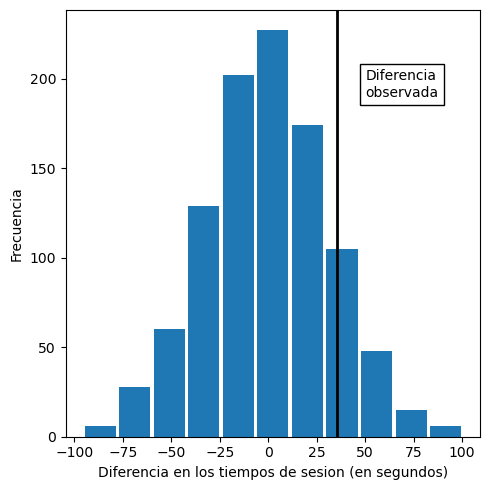

In [8]:
# semilla para la generacion de numeros aleatorios
random.seed(1)
# lista de 1000 diferencias de medias simuladas
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

# distribucion de diferencias de medias
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_B - mean_A, color='black', lw=2)
ax.text(50, 190, 'Diferencia\nobservada', bbox={'facecolor':'white'})
ax.set_xlabel('Diferencia en los tiempos de sesion (en segundos)')
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Finalizamos la prueba calculando una estimacion del p-value, que mide la probabilidad de observar una diferencia de medias tan extrema que la real bajo la hipotesis de que no hay diferencia entre grupos (hipotesis nula)

In [9]:
# convertir lista de diferencias simuladas en un arreglo
perm_diffs = np.array(perm_diffs)
# calcular la proporcion de valores que son mayores que la diferencia observada
print(np.mean(perm_diffs > mean_B - mean_A))

0.121


> La grafica muestra que la diferencia media de las permutaciones aleatorias a menudo excede la diferencia observada en los tiempos de sesion. Esto ocurre en el 12.1% de los casos y sugiere que la diferencia observada en el tiempo de sesion entre la pagina A y B esta dentro del rango de variacion por azar, y por tanto, no es estadisticamente significativo.

### Prueba de significancia

Considere los resultados de una prueba web. El precio A convierte casi un 5% mejor que el precio B (una diferencia de 0.0368 puntos porcentuales), lo suficientemente grande como para ser significativo en un negocio de alto volumen

- Conversion de A: 182/(22406+182)*100 = 0.8057%
- Conversion de B: 200/(23539+200)*100 = 0.8425%

Vamos a probar si la diferencia entre los precios A y B esta dentro del rango de variacion por azar (hipotesis nula: no hay diferencia entre las tasas)

> Si los precios comparten la misma tasa de conversion, podria la variacion por azar producir una diferencia tan grande como el 5%?

In [10]:
# semilla
random.seed()
# diferencia de conversion entre el precio A y B
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Diferencia observada: {obs_pct_diff:.4f}%')

Diferencia observada: 0.0368%


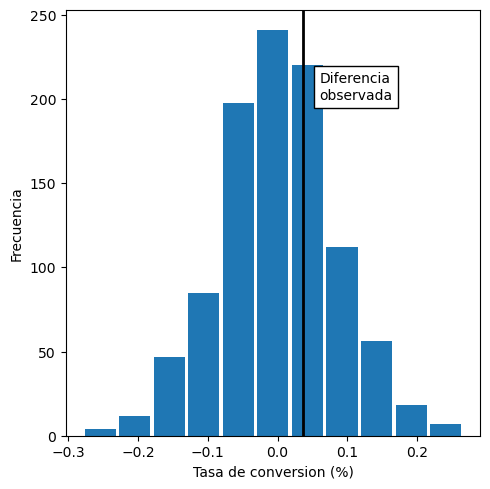

In [11]:
# crear muestra binaria para simular resultados de conversion
conversion = [0] * 45945 # lista de ceros
conversion.extend([1] * 382) # lista de unos
conversion = pd.Series(conversion) # convertir en serie

# calcula la diferencia de la tasa de conversion entre dos grupos
# seleccionados aleatoriamente de la muestra total
perm_diffs = [100 * perm_fun(conversion, 23739, 22588) for _ in range(1000)]

# histograma
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Diferencia\nobservada', bbox={'facecolor':'white'})
ax.set_xlabel('Tasa de conversion (%)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

> La diferencia observada de 0.0368% esta dentro del rango de variacion por azar

### P-value

Vamos a calcular el valor p de la prueba anterior para mostrar cuantitativamente si la diferencia es estadisticamente significativa.

In [12]:
# np.mean sobre una lista de booleanos devuelve el porcentaje de veces que se 
# encontró True en la lista
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


> Este valor significa que esperariamos obtener un resultado tan extremo como este o un resultado mas extremo, por azar mas del 30% de las veces.

Por otro lado, podemos calcular el valor p a traves de la aproximacion normal o prueba chi-cuadrado ya que esta proporciona una forma estandarizada de aproximar el valor p sin necesidad de realizar miles de permutaciones computacionales.

Esta prueba utiliza datos de conteo (clics vs no clics) y asume la hipotesis nula de independencia (no hay diferencia real entre los grupos. Los precios A y B tienen la misma tasa de conversion) 

- Se calcula cuantas conversiones deberian haber ocurrido en cada grupo si la tasa fuera exactamente igual para ambos.

- Se calcula los residuales de Pearson que miden que tanto se alejan los datos reales de los esperados.

- Se obtiene el estadistico Chi Cuadrado y se compara con una distribucion de referencia para obtener el valor p.

In [13]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value para una prueba unilateral: {p_value / 2:.4f}')

p-value para una prueba unilateral: 0.3498


> La aproximacion normal arroja un valor p de 0.3498, que es cercano al valor p obtenido de la prueba de permutacion. Esto confirma que la diferencia observada del 5% en conversiones podia deberse simplemente al azar.

### t-Test

Continuando con el ejemplo anterior, vamos a implementar una prueba t para obtener el valor p de forma tradicional.

Vamos a comparar los tiempos de sesion de dos grupos: A y B. Esta prueba se ejecuta para muestras independientes y busca determinar si existe una diferencia significativa entre las medias de ambos grupos.

In [ ]:
# prueba t-test
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,  # valores de Time del grupa A
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False # no asume igualdad de varianza entre los grupos
                      )

# dividir p entre 2 debido a que t-test es bilateral
print(f'p valor para una prueba unilateral: {res.pvalue/2:.4f}')

p valor para un solo lado del test: 0.1408


> Es importante tener claro que el valor p representa la probabilidad de observar una diferencia igual o mas extrema que la observada, bajo la hipotesis nula de que ambas medias son iguales.

> El valor obtenido es de 0.1408, bastante cerca al obtenido de las pruebas de permutacion (0.121) 